# 08. Проверка гипотез без leakage-признаков

Гипотезы проверяются только по `answer`, `description` и целевой переменной `difficulty`. Поведенческие статистики прохождения не используются, потому что `difficulty` вычисляется из них напрямую.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

## Загрузка и разрешенные признаки

In [2]:
DATA_PATH = Path("../data.csv")
df = pd.read_csv(DATA_PATH)

RARE_LETTERS = set("фщъёцэ")
LEAKAGE_COLUMNS = ["started", "solved", "users_with_hints", "total_hints", "solve_rate", "hint_usage", "avg_hints"]

hyp_df = df.copy()
hyp_df["answer_main"] = hyp_df["answer"].astype(str).str.split("|").str[0].str.strip()
hyp_df["answer_compact"] = hyp_df["answer_main"].str.replace(" ", "", regex=False)
hyp_df["answer_len"] = hyp_df["answer_compact"].str.len()
hyp_df["answer_word_count"] = hyp_df["answer_main"].str.split().str.len()
hyp_df["description_len"] = hyp_df["description"].astype(str).str.len()
hyp_df["description_word_count"] = hyp_df["description"].astype(str).str.split().str.len()
hyp_df["variant_count"] = hyp_df["answer"].astype(str).str.count(r"\|") + 1
hyp_df["answer_rare_ratio"] = hyp_df["answer_compact"].apply(
    lambda text: sum(char in RARE_LETTERS for char in str(text).lower()) / len(str(text)) if len(str(text)) else 0.0
)
hyp_df["description_has_rebus_terms"] = hyp_df["description"].astype(str).str.lower().str.contains(
    "запятая|перевернут|зачерк|буква|цифра", regex=True
).astype(int)

hypothesis_feature_cols = [
    "answer_len",
    "answer_word_count",
    "description_len",
    "description_word_count",
    "variant_count",
    "answer_rare_ratio",
    "description_has_rebus_terms",
]
assert not set(hypothesis_feature_cols) & set(LEAKAGE_COLUMNS)

hyp_df[["answer", "description", *hypothesis_feature_cols, "difficulty"]].head()

,answer,description,answer_len,answer_word_count,description_len,description_word_count,variant_count,answer_rare_ratio,description_has_rebus_terms,difficulty
0,брауни,Коричневая английская Е (читается как и) = Bro...,6,1,72,13,1,0.0,0,0.4303
1,tralalelo tralala|тралалело тралала|тралалеро ...,Один из самых известных героев мема BrainRot -...,16,2,65,11,4,0.0,0,0.4010
2,свитер|свита,Свитер или Свита. Сладкая буква R. (sweet R). ...,6,1,73,15,2,0.0,1,0.3736
3,подоконник,Под О Конь и К,10,1,14,5,1,0.0,0,0.2045
4,редактор,Красный актер = Red Actor,8,1,25,5,1,0.0,0,0.3675


## Гипотеза 1: более длинный answer связан со сложностью

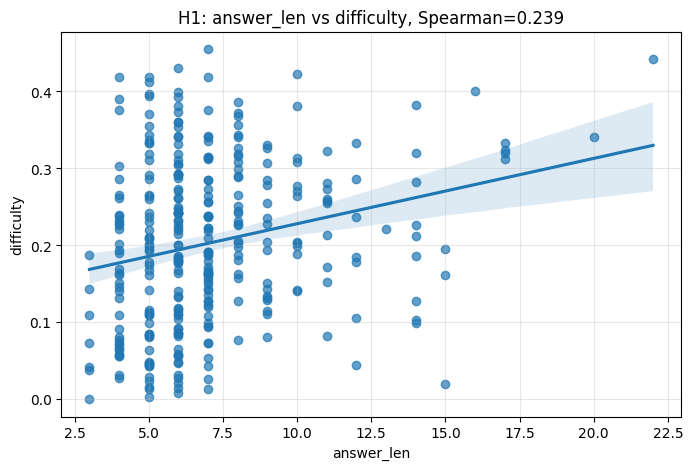

Гипотеза 1: подтверждается. Spearman correlation = 0.239


In [3]:
h1_corr = hyp_df[["answer_len", "difficulty"]].corr(method="spearman").iloc[0, 1]

plt.figure(figsize=(8, 5))
sns.regplot(data=hyp_df, x="answer_len", y="difficulty", scatter_kws={"alpha": 0.7})
plt.title(f"H1: answer_len vs difficulty, Spearman={h1_corr:.3f}")
plt.grid(True, alpha=0.3)
plt.show()

h1_result = "подтверждается" if abs(h1_corr) >= 0.2 else "не получает сильного подтверждения"
print(f"Гипотеза 1: {h1_result}. Spearman correlation = {h1_corr:.3f}")

## Гипотеза 2: более длинное description связано со сложностью

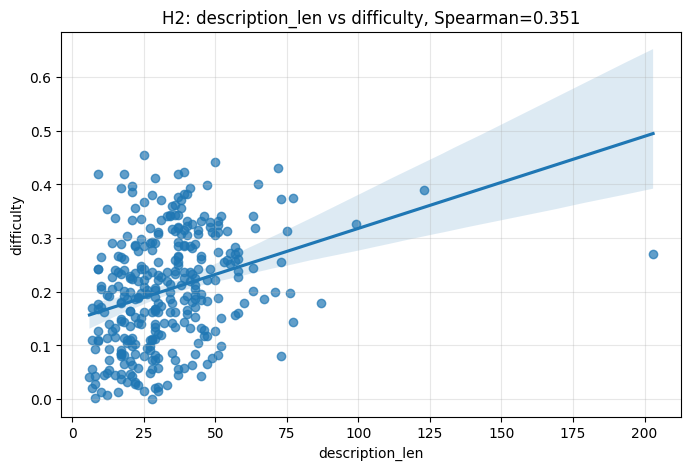

Гипотеза 2: подтверждается. Spearman correlation = 0.351


In [4]:
h2_corr = hyp_df[["description_len", "difficulty"]].corr(method="spearman").iloc[0, 1]

plt.figure(figsize=(8, 5))
sns.regplot(data=hyp_df, x="description_len", y="difficulty", scatter_kws={"alpha": 0.7})
plt.title(f"H2: description_len vs difficulty, Spearman={h2_corr:.3f}")
plt.grid(True, alpha=0.3)
plt.show()

h2_result = "подтверждается" if abs(h2_corr) >= 0.2 else "не получает сильного подтверждения"
print(f"Гипотеза 2: {h2_result}. Spearman correlation = {h2_corr:.3f}")

## Гипотеза 3: несколько вариантов answer связаны со сложностью

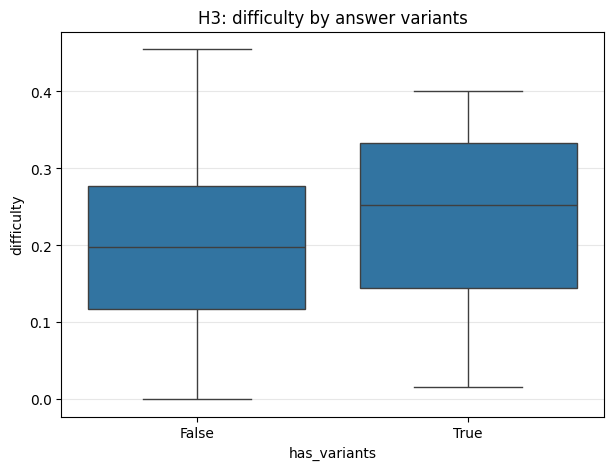

Гипотеза 3: сильной разницы не видно. Difference in mean difficulty = 0.026


In [5]:
single_variant = hyp_df[hyp_df["variant_count"] == 1]["difficulty"]
multi_variant = hyp_df[hyp_df["variant_count"] > 1]["difficulty"]
variant_diff = multi_variant.mean() - single_variant.mean()

plt.figure(figsize=(7, 5))
sns.boxplot(data=hyp_df.assign(has_variants=hyp_df["variant_count"] > 1), x="has_variants", y="difficulty")
plt.title("H3: difficulty by answer variants")
plt.grid(True, axis="y", alpha=0.3)
plt.show()

h3_result = "есть заметная разница" if abs(variant_diff) >= 0.03 else "сильной разницы не видно"
print(f"Гипотеза 3: {h3_result}. Difference in mean difficulty = {variant_diff:.3f}")

## Гипотеза 4: rebus-термины в description связаны со сложностью

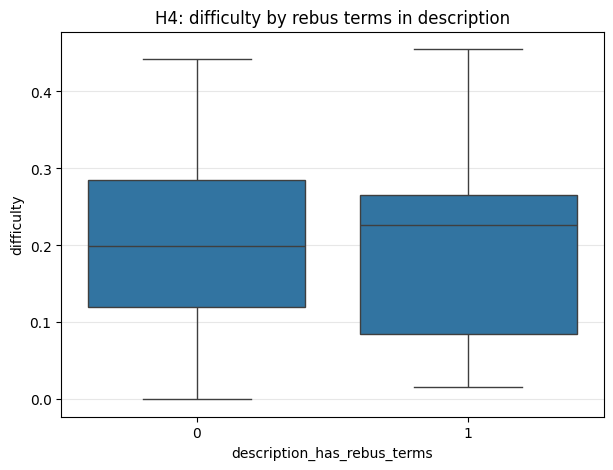

Гипотеза 4: сильной разницы не видно. Difference in mean difficulty = -0.008


In [6]:
without_terms = hyp_df[hyp_df["description_has_rebus_terms"] == 0]["difficulty"]
with_terms = hyp_df[hyp_df["description_has_rebus_terms"] == 1]["difficulty"]
terms_diff = with_terms.mean() - without_terms.mean()

plt.figure(figsize=(7, 5))
sns.boxplot(data=hyp_df, x="description_has_rebus_terms", y="difficulty")
plt.title("H4: difficulty by rebus terms in description")
plt.grid(True, axis="y", alpha=0.3)
plt.show()

h4_result = "есть заметная разница" if abs(terms_diff) >= 0.03 else "сильной разницы не видно"
print(f"Гипотеза 4: {h4_result}. Difference in mean difficulty = {terms_diff:.3f}")

## Итоговая таблица гипотез

In [7]:
hypothesis_results = pd.DataFrame(
    [
        {"hypothesis": "Длина answer связана со сложностью", "feature_source": "answer", "metric": "Spearman(answer_len, difficulty)", "value": h1_corr, "result": h1_result},
        {"hypothesis": "Длина description связана со сложностью", "feature_source": "description", "metric": "Spearman(description_len, difficulty)", "value": h2_corr, "result": h2_result},
        {"hypothesis": "Несколько вариантов answer связаны со сложностью", "feature_source": "answer", "metric": "difference in mean difficulty", "value": variant_diff, "result": h3_result},
        {"hypothesis": "Rebus-термины в description связаны со сложностью", "feature_source": "description", "metric": "difference in mean difficulty", "value": terms_diff, "result": h4_result},
    ]
)

hypothesis_results

,hypothesis,feature_source,metric,value,result
0,Длина answer связана со сложностью,answer,"Spearman(answer_len, difficulty)",0.238541,подтверждается
1,Длина description связана со сложностью,description,"Spearman(description_len, difficulty)",0.351054,подтверждается
2,Несколько вариантов answer связаны со сложностью,answer,difference in mean difficulty,0.026476,сильной разницы не видно
3,Rebus-термины в description связаны со сложностью,description,difference in mean difficulty,-0.007845,сильной разницы не видно
